# Development of an Ensemble Machine Learning Framework for Early Dementia and Alzheimer's Disease Classification with a Prototype Decision Support System

**Student:** Ayomide Agbenike


## Purpose and scope

This notebook develops and evaluates an ensemble machine-learning framework using demographic, cognitive and derived MRI-volume variables. Five individual classifiers are compared with soft-voting and stacking ensembles. Model development is performed using the OASIS-1 cross-sectional dataset, while baseline observations from OASIS-2 are reserved for an independent assessment of generalisation.

The prediction target is binary cognitive status: `CDR = 0` or `CDR > 0`. Clinical Dementia Rating (CDR) is associated with dementia severity in these datasets, but the resulting prediction is not an independent diagnosis of Alzheimer's disease. This model and prototype were developed for university research. Their predictions indicate patterns associated with cognitive status in the OASIS datasets and should not be interpreted as a medical diagnosis.

### Relationship to the research question

The experiment examines whether combining different machine-learning models improves classification performance and stability compared with using individual models. It also tests how well the selected model performs on previously unseen participants from a separate dataset. This directly supports the dissertation objectives concerning individual-model training, ensemble development, model comparison and prototype implementation.


## 1. Reproducibility and data identification

The two tabular files were downloaded from Boysen's *MRI and Alzheimers* dataset on Kaggle. The files reproduce demographic, cognitive and derived MRI measures from the Open Access Series of Imaging Studies (OASIS). OASIS-1 and OASIS-2 were created using different study designs and are therefore not merged for model training. OASIS-1 is used for development, and OASIS-2 is retained as a separate independent test sample (Boysen, n.d.; Marcus et al., 2007; Marcus et al., 2010).

The following cell records the software versions and SHA-256 fingerprint of each input file. These fingerprints allow the exact files used in the final experiment to be identified without redistributing participant-level data.


In [1]:
from pathlib import Path
import hashlib, json, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, brier_score_loss, confusion_matrix)
from sklearn.calibration import calibration_curve

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore', category=FutureWarning)

def locate(names):
    roots = [Path.cwd(), Path.cwd().parent, Path.home() / 'Downloads']
    for root in roots:
        for name in names:
            candidate = root / name
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f'Could not locate any of {names}. Upload both OASIS files to the Colab Files panel.')

def sha256(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as file:
        for block in iter(lambda: file.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

cross_path = locate(['oasis_cross-sectional.csv', 'oasis_cross-sectional.xls'])
long_path = locate(['oasis_longitudinal.csv', 'oasis_longitudinal.xls'])

environment = {
    'Python': platform.python_version(),
    'scikit-learn': sklearn.__version__,
    'NumPy': np.__version__,
    'pandas': pd.__version__,
    'Cross-sectional SHA256': sha256(cross_path),
    'Longitudinal SHA256': sha256(long_path),
}
print('Cross-sectional source:', cross_path)
print('Longitudinal source:', long_path)
display(pd.Series(environment, name='Value').to_frame())


Cross-sectional source: /content/oasis_cross-sectional.csv
Longitudinal source: /content/oasis_longitudinal.csv


,Value
Python,3.13.15
scikit-learn,1.6.1
NumPy,2.1.3
pandas,2.2.3
Cross-sectional SHA256,059f0c5ea237a20e1455c2a22decac1224f542bf108d7b...
Longitudinal SHA256,d2f0a15ff35fa4a65c35c064b848fc1b396e9d2f4aec93...


## 2. Dataset preparation and prediction target

Only OASIS-1 records containing a recorded Clinical Dementia Rating (CDR) were included in the analysis. Records with a missing CDR were excluded because their cognitive status could not be confirmed from the available data. They were not automatically classified according to age or another input variable. The resulting development sample contained 235 participants: 135 with `CDR = 0` and 100 with `CDR > 0`.

For OASIS-2, only the first recorded visit for each participant was used. This ensured that each participant appeared once in the independent test sample and prevented repeated observations from the same person from influencing the evaluation. The test sample contained 150 participants: 85 with `CDR = 0` and 65 with `CDR > 0`.

Seven input variables available in both datasets were selected: sex, age, socioeconomic status (SES), Mini-Mental State Examination (MMSE) score, estimated total intracranial volume (eTIV), normalised whole-brain volume (nWBV), and atlas scaling factor (ASF). Education was excluded because it was recorded differently in OASIS-1 and OASIS-2. CDR was used only to create the target categories and was not included among the model inputs.

The target categories were defined as:

- `CDR = 0`: no recorded cognitive impairment.
- `CDR > 0`: recorded cognitive impairment or dementia.


In [2]:
cross_raw = pd.read_csv(cross_path)
long_raw = pd.read_csv(long_path)

features = ['M/F', 'Age', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
numeric_features = ['Age', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
categorical_features = ['M/F']

# Development sample: retain only records with an observed CDR outcome.
cross = cross_raw.loc[cross_raw['CDR'].notna()].copy()
cross['Participant_ID'] = cross['ID'].str.replace(r'_MR\d+$', '', regex=True)
cross['Target'] = (cross['CDR'] > 0).astype(int)

# Independent test sample: one baseline record per longitudinal participant and observed CDR only.
long_base = long_raw.loc[(long_raw['Visit'] == 1) & long_raw['CDR'].notna()].copy()
long_base['Participant_ID'] = long_base['Subject ID'].astype(str)
long_base['Target'] = (long_base['CDR'] > 0).astype(int)

X_dev, y_dev, groups_dev = cross[features], cross['Target'], cross['Participant_ID']
X_ext, y_ext, groups_ext = long_base[features], long_base['Target'], long_base['Participant_ID']

summary = pd.DataFrame({
    'Analysis sample': ['OASIS-1 development sample', 'OASIS-2 independent test sample'],
    'Records': [len(cross), len(long_base)],
    'Unique participants': [cross['Participant_ID'].nunique(), long_base['Participant_ID'].nunique()],
    'CDR = 0': [(y_dev == 0).sum(), (y_ext == 0).sum()],
    'CDR > 0': [(y_dev == 1).sum(), (y_ext == 1).sum()],
})
display(summary)
print('Development missingness:')
display(X_dev.isna().sum().to_frame('Missing'))
print('External-test missingness:')
display(X_ext.isna().sum().to_frame('Missing'))

assert cross_raw['CDR'].notna().sum() == len(cross), 'Only observed labels may enter development.'
assert long_base['Participant_ID'].is_unique, 'External baseline must contain one record per participant.'
assert 'CDR' not in features, 'CDR must not be used as a predictor.'


,Analysis sample,Records,Unique participants,CDR = 0,CDR > 0
0,OASIS-1 development sample,235,235,135,100
1,OASIS-2 independent test sample,150,150,85,65


Development missingness:


,Missing
M/F,0
Age,0
SES,19
MMSE,0
eTIV,0
nWBV,0
ASF,0


External-test missingness:


,Missing
M/F,0
Age,0
SES,8
MMSE,0
eTIV,0
nWBV,0
ASF,0


## 3. Preprocessing, individual models and ensembles

Median imputation is used for missing numerical values, while the most frequent category is used for a missing categorical value. Numerical variables are standardised and sex is one-hot encoded. All preprocessing is placed inside each model pipeline; consequently, imputation, encoding and scaling are learned from training data only during cross-validation.

The individual classifiers represent different modelling assumptions:

- Logistic Regression provides a comparatively simple linear baseline.
- The radial-basis SVM represents a non-linear margin-based method.
- Decision Tree provides a rule-based non-linear classifier.
- Random Forest averages multiple trees to reduce the instability of an individual tree.
- Gradient Boosting builds trees sequentially to correct earlier errors.

Soft voting averages the predicted positive-class probabilities from the five tuned individual models. Stacking instead uses out-of-fold base-model probabilities as inputs to a Logistic Regression meta-learner. The limited hyperparameter grids balance model optimisation against the size of the development sample and available computational resources.

Macro F1 is specified before model comparison as the primary selection measure because it gives equal importance to the two outcome classes. Accuracy, balanced accuracy, precision, sensitivity, specificity, positive-class F1, ROC-AUC and Brier score provide complementary evidence.


In [3]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary')),
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipe, numeric_features),
    ('categorical', categorical_pipe, categorical_features),
])

estimators = {
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}
param_grids = {
    'Logistic Regression': {'model__C': [0.1, 1.0], 'model__class_weight': [None, 'balanced']},
    'SVM (RBF)': {'model__C': [0.5, 2.0, 10.0], 'model__class_weight': [None, 'balanced']},
    'Decision Tree': {'model__max_depth': [3, 6, None], 'model__class_weight': [None, 'balanced']},
    'Random Forest': {'model__n_estimators': [250], 'model__max_depth': [5, None], 'model__class_weight': [None, 'balanced']},
    'Gradient Boosting': {'model__n_estimators': [100, 200], 'model__learning_rate': [0.03, 0.1]},
}

def pipeline_for(estimator):
    return Pipeline([('preprocess', clone(preprocessor)), ('model', clone(estimator))])

def metric_row(name, fold, y_true, prob):
    pred = (np.asarray(prob) >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        'Model': name, 'Fold': fold,
        'Accuracy': accuracy_score(y_true, pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall/Sensitivity': recall_score(y_true, pred, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) else np.nan,
        'Positive-class F1': f1_score(y_true, pred, zero_division=0),
        'Macro F1': f1_score(y_true, pred, average='macro', zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, prob),
        'Brier score': brier_score_loss(y_true, prob),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    }

def fit_tuned_models(X, y, inner_cv):
    fitted, parameters = {}, {}
    for name, estimator in estimators.items():
        search = GridSearchCV(
            pipeline_for(estimator), param_grids[name], scoring='f1_macro',
            cv=inner_cv, n_jobs=1, refit=True
        )
        search.fit(X, y)
        fitted[name] = search.best_estimator_
        parameters[name] = search.best_params_
    return fitted, parameters

def stacking_oof(X, y, fitted_templates, inner_cv):
    names = list(fitted_templates)
    oof = np.zeros((len(X), len(names)))
    for train_index, validation_index in inner_cv.split(X, y):
        for column, name in enumerate(names):
            model = clone(fitted_templates[name])
            model.fit(X.iloc[train_index], y.iloc[train_index])
            oof[validation_index, column] = model.predict_proba(X.iloc[validation_index])[:, 1]
    meta = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE)
    meta.fit(oof, y)
    return meta, names

def probabilities_for_all(base_models, meta_model, stack_names, X):
    probabilities = {name: model.predict_proba(X)[:, 1] for name, model in base_models.items()}
    probabilities['Soft Voting Ensemble'] = np.column_stack(list(probabilities.values())).mean(axis=1)
    meta_features = np.column_stack([base_models[name].predict_proba(X)[:, 1] for name in stack_names])
    probabilities['Stacking Ensemble'] = meta_model.predict_proba(meta_features)[:, 1]
    return probabilities

def make_bundle(name, base_models, meta_model, stack_names, features):
    common = {'name': name, 'features': features, 'target': 'CDR = 0 versus CDR > 0', 'threshold': 0.5}
    if name in base_models:
        return {**common, 'type': 'single', 'model': base_models[name]}
    if name == 'Soft Voting Ensemble':
        return {**common, 'type': 'soft_voting', 'models': base_models}
    return {**common, 'type': 'stacking', 'models': base_models,
            'meta_model': meta_model, 'model_order': stack_names}


## 4. Nested stratified cross-validation

Five-fold nested stratified cross-validation is used on OASIS-1. The outer folds estimate unseen-data performance. Within each outer training fold, four-fold stratified cross-validation selects hyperparameters. The stacking meta-learner is trained from out-of-fold probabilities rather than predictions produced on the same observations used to fit its base models. The fixed random seed supports repeatability.

Model selection uses only mean outer-fold Macro F1. OASIS-2 is not examined when choosing the architecture, preserving its role as an independent generalisation assessment. Nested validation is used because selecting hyperparameters and reporting performance from the same folds can produce optimistic estimates (Varma & Simon, 2006).


In [4]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_metrics, prediction_rows, tuning_history = [], [], []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_dev, y_dev), start=1):
    X_train, X_test = X_dev.iloc[train_idx], X_dev.iloc[test_idx]
    y_train, y_test = y_dev.iloc[train_idx], y_dev.iloc[test_idx]

    inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE + fold)
    fitted, params = fit_tuned_models(X_train, y_train, inner_cv)
    tuning_history.append({'Fold': fold, **params})

    stack_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE + fold)
    meta, stack_names = stacking_oof(X_train, y_train, fitted, stack_cv)
    all_probabilities = probabilities_for_all(fitted, meta, stack_names, X_test)

    for name, probabilities in all_probabilities.items():
        fold_metrics.append(metric_row(name, fold, y_test, probabilities))
        for row_position, original_index in enumerate(test_idx):
            prediction_rows.append({
                'Fold': fold, 'Model': name,
                'Participant_ID': groups_dev.iloc[original_index],
                'Observed': int(y_dev.iloc[original_index]),
                'Probability': float(probabilities[row_position]),
                'Predicted': int(probabilities[row_position] >= 0.5),
            })

metrics_df = pd.DataFrame(fold_metrics)
predictions_df = pd.DataFrame(prediction_rows)
summary_df = metrics_df.groupby('Model').agg(
    **{metric: (metric, 'mean') for metric in ['Accuracy','Balanced Accuracy','Precision','Recall/Sensitivity','Specificity','Positive-class F1','Macro F1','ROC-AUC','Brier score']},
    Macro_F1_SD=('Macro F1', 'std')
).reset_index().sort_values(['Macro F1', 'ROC-AUC'], ascending=[False, False])

best_name = summary_df.iloc[0]['Model']
ensemble_summary = summary_df[summary_df['Model'].isin(['Soft Voting Ensemble', 'Stacking Ensemble'])]
best_ensemble_name = ensemble_summary.iloc[0]['Model']

display(summary_df.round(4))
print('Prespecified primary metric: mean outer-fold Macro F1')
print('Overall selected architecture:', best_name)
print('Best ensemble architecture:', best_ensemble_name)


,Model,Accuracy,Balanced Accuracy,Precision,Recall/Sensitivity,Specificity,Positive-class F1,Macro F1,ROC-AUC,Brier score,Macro_F1_SD
5,Soft Voting Ensemble,0.8255,0.8183,0.8234,0.77,0.8667,0.7901,0.8196,0.9096,0.1237,0.0555
3,Random Forest,0.8255,0.8183,0.8282,0.77,0.8667,0.7892,0.8189,0.9189,0.1188,0.0616
1,Gradient Boosting,0.8255,0.8144,0.8397,0.74,0.8889,0.7835,0.8184,0.9069,0.1256,0.0375
6,Stacking Ensemble,0.8213,0.8146,0.8125,0.77,0.8593,0.7841,0.8148,0.9100,0.1259,0.0512
0,Decision Tree,0.8085,0.7931,0.8407,0.69,0.8963,0.7522,0.7976,0.8263,0.1696,0.0462
2,Logistic Regression,0.8000,0.7909,0.7958,0.73,0.8519,0.7541,0.7918,0.8985,0.1363,0.0523
4,SVM (RBF),0.7872,0.7798,0.7671,0.73,0.8296,0.7426,0.7798,0.8870,0.1403,0.0585


Prespecified primary metric: mean outer-fold Macro F1
Overall selected architecture: Soft Voting Ensemble
Best ensemble architecture: Soft Voting Ensemble


### 4.1 Internal-validation findings

Soft voting achieved the highest mean outer-fold Macro F1 (`0.8196`, SD `0.0555`) and was therefore selected. Random Forest produced a nearly identical Macro F1 (`0.8189`) and the highest internal ROC-AUC (`0.9189`). Stacking achieved a Macro F1 of `0.8148` and ROC-AUC of `0.9100`.

The difference between soft voting and Random Forest was only `0.0007` Macro F1. The result therefore provides evidence of a marginal rather than substantial internal advantage for the selected ensemble. The close scores also show why several metrics and an independent sample are needed instead of relying on accuracy alone.


## 5. Independent OASIS-2 evaluation

After internal model selection, each architecture is refitted using all eligible OASIS-1 development records. Hyperparameter selection remains confined to OASIS-1. Every completed architecture is then evaluated on the untouched OASIS-2 baseline sample. Evaluating all models reveals whether their relative performance is consistent across the two datasets, but the external results are not used retrospectively to change the selected architecture.

Bootstrap 95% confidence intervals are calculated for the selected model's external ROC-AUC and Macro F1. A sex-based subgroup analysis is also reported as an exploratory check. It is not interpreted as a comprehensive fairness assessment because the sample is small and other demographic attributes are unavailable.


In [5]:
final_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + 100)
final_base, final_params = fit_tuned_models(X_dev, y_dev, final_cv)
final_stack_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + 100)
final_meta, final_stack_names = stacking_oof(X_dev, y_dev, final_base, final_stack_cv)

# Every architecture is evaluated on the untouched OASIS-2 independent test sample.
external_probabilities = probabilities_for_all(final_base, final_meta, final_stack_names, X_ext)
external_metrics = pd.DataFrame([
    metric_row(name, 'External', y_ext, probability)
    for name, probability in external_probabilities.items()
]).sort_values(['Macro F1', 'ROC-AUC'], ascending=[False, False])
display(external_metrics.drop(columns=['Fold']).round(4))

# The independent test sample is for final generalisation assessment, not model selection.
selected_external_prob = external_probabilities[best_name]
selected_bundle = make_bundle(best_name, final_base, final_meta, final_stack_names, features)
best_ensemble_bundle = make_bundle(best_ensemble_name, final_base, final_meta, final_stack_names, features)

def bootstrap_ci(y_true, probability, metric_fn, repetitions=2000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_array, probability_array = np.asarray(y_true), np.asarray(probability)
    values = []
    for _ in range(repetitions):
        index = rng.integers(0, len(y_array), len(y_array))
        if np.unique(y_array[index]).size < 2:
            continue
        values.append(metric_fn(y_array[index], probability_array[index]))
    return np.percentile(values, [2.5, 97.5])

ci_auc = bootstrap_ci(y_ext, selected_external_prob, roc_auc_score)
ci_macro_f1 = bootstrap_ci(
    y_ext, selected_external_prob,
    lambda observed, probability: f1_score(observed, probability >= 0.5, average='macro', zero_division=0)
)
print(f'Selected model external ROC-AUC 95% bootstrap CI: {ci_auc[0]:.3f} to {ci_auc[1]:.3f}')
print(f'Selected model external Macro F1 95% bootstrap CI: {ci_macro_f1[0]:.3f} to {ci_macro_f1[1]:.3f}')

external_prediction_rows = []
for name, probability in external_probabilities.items():
    for row_position in range(len(X_ext)):
        external_prediction_rows.append({
            'Model': name,
            'Participant_ID': groups_ext.iloc[row_position],
            'Sex': X_ext['M/F'].iloc[row_position],
            'Observed': int(y_ext.iloc[row_position]),
            'Probability': float(probability[row_position]),
            'Predicted': int(probability[row_position] >= 0.5),
        })
external_predictions = pd.DataFrame(external_prediction_rows)

selected_external_predictions = external_predictions[external_predictions['Model'] == best_name]
subgroup_rows = []
for sex, part in selected_external_predictions.groupby('Sex'):
    if part['Observed'].nunique() == 2:
        row = metric_row(f'{best_name} - Sex {sex}', 'External', part['Observed'], part['Probability'])
        row['Subgroup N'] = len(part)
        subgroup_rows.append(row)
subgroup_metrics = pd.DataFrame(subgroup_rows)
display(subgroup_metrics.round(4))


,Model,Accuracy,Balanced Accuracy,Precision,Recall/Sensitivity,Specificity,Positive-class F1,Macro F1,ROC-AUC,Brier score,TN,FP,FN,TP
3,Random Forest,0.8933,0.8896,0.8889,0.8615,0.9176,0.8750,0.8910,0.9575,0.0818,78,7,9,56
6,Stacking Ensemble,0.8933,0.8878,0.9016,0.8462,0.9294,0.8730,0.8905,0.9365,0.0998,79,6,10,55
5,Soft Voting Ensemble,0.8733,0.8629,0.9107,0.7846,0.9412,0.8430,0.8684,0.9350,0.1035,80,5,14,51
4,Gradient Boosting,0.8600,0.8620,0.8143,0.8769,0.8471,0.8444,0.8586,0.9399,0.0953,72,13,8,57
2,Decision Tree,0.8400,0.8172,0.9767,0.6462,0.9882,0.7778,0.8264,0.8970,0.1177,84,1,23,42
0,Logistic Regression,0.8133,0.7937,0.8936,0.6462,0.9412,0.7500,0.8005,0.8442,0.1519,80,5,23,42
1,SVM (RBF),0.7733,0.7729,0.7246,0.7692,0.7765,0.7463,0.7707,0.8671,0.1465,66,19,15,50


Selected model external ROC-AUC 95% bootstrap CI: 0.894 to 0.971
Selected model external Macro F1 95% bootstrap CI: 0.810 to 0.920


,Model,Fold,Accuracy,Balanced Accuracy,Precision,Recall/Sensitivity,Specificity,Positive-class F1,Macro F1,ROC-AUC,Brier score,TN,FP,FN,TP,Subgroup N
0,Soft Voting Ensemble - Sex F,External,0.9091,0.8621,1.0000,0.7241,1.0000,0.8400,0.8883,0.9433,0.0838,59,0,8,21,88
1,Soft Voting Ensemble - Sex M,External,0.8226,0.8205,0.8571,0.8333,0.8077,0.8451,0.8188,0.8985,0.1314,21,5,6,30,62


### 5.1 External findings

The selected soft-voting ensemble achieved external accuracy of `0.8733`, balanced accuracy of `0.8629`, sensitivity of `0.7846`, specificity of `0.9412`, positive-class F1 of `0.8430`, Macro F1 of `0.8684`, and ROC-AUC of `0.9350`. Its confusion matrix contained 80 true negatives, 5 false positives, 14 false negatives and 51 true positives. The 95% bootstrap intervals were `0.894–0.971` for ROC-AUC and `0.810–0.920` for Macro F1.

Random Forest and stacking both achieved external accuracy of `0.8933` and slightly higher external Macro F1 values (`0.8910` and `0.8905`, respectively). Random Forest also produced the highest external ROC-AUC (`0.9575`). These results do not replace the internally selected model; instead, they demonstrate that rankings can change between the two datasets. This finding qualifies the claim that one architecture is universally superior.

For the selected model, exploratory Macro F1 was `0.8883` for women (`n = 88`) and `0.8188` for men (`n = 62`). The difference is reported as a potential subgroup concern, but no causal or population-wide conclusion can be drawn from these sample sizes.


## 6. Evaluation figures and reproducible artefacts

The following figure combines the selected model's external confusion matrix, an external calibration plot and the internal Macro F1 comparison. Calibration is included because a decision-support prototype presents probabilities; a probability should not be interpreted only through classification accuracy. The exported CSV files retain fold-level and participant-level evidence so that all reported summaries can be checked.


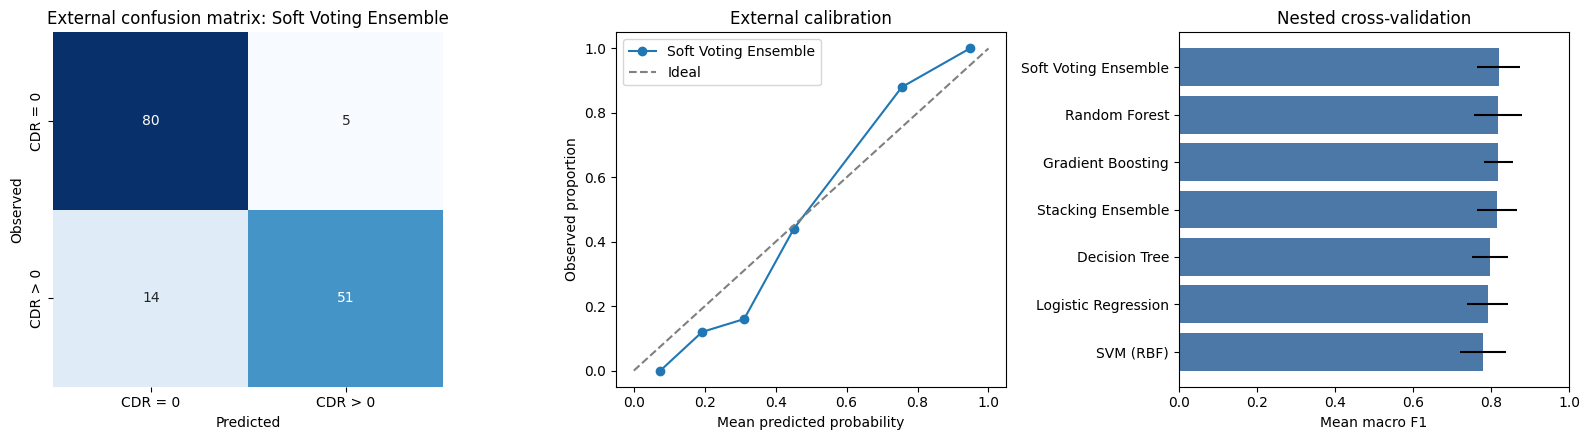

Saved final dissertation outputs to: /content/final_dissertation_model_outputs
Overall selected architecture: Soft Voting Ensemble
Best ensemble architecture: Soft Voting Ensemble
Interpretation: the target is observed CDR-based cognitive status; the output is not a clinical diagnosis.


In [6]:
selected_external_predictions = external_predictions[external_predictions['Model'] == best_name]
selected_external_prediction = selected_external_predictions['Predicted'].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm = confusion_matrix(y_ext, selected_external_prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['CDR = 0', 'CDR > 0'], yticklabels=['CDR = 0', 'CDR > 0'])
axes[0].set_title(f'External confusion matrix: {best_name}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Observed')

prob_true, prob_pred = calibration_curve(y_ext, selected_external_prob, n_bins=6, strategy='quantile')
axes[1].plot(prob_pred, prob_true, marker='o', label=best_name)
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='Ideal')
axes[1].set(xlabel='Mean predicted probability', ylabel='Observed proportion', title='External calibration')
axes[1].legend()

plot_df = summary_df.sort_values('Macro F1')
axes[2].barh(plot_df['Model'], plot_df['Macro F1'], xerr=plot_df['Macro_F1_SD'], color='#4C78A8')
axes[2].set(xlabel='Mean macro F1', title='Nested cross-validation')
axes[2].set_xlim(0, 1)

plt.tight_layout()

results_dir = Path.cwd() / 'final_dissertation_model_outputs'
results_dir.mkdir(exist_ok=True)
figure_path = results_dir / 'final_model_evaluation.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

summary_df.to_csv(results_dir / 'nested_cv_summary.csv', index=False)
metrics_df.to_csv(results_dir / 'nested_cv_fold_metrics.csv', index=False)
predictions_df.to_csv(results_dir / 'nested_cv_predictions.csv', index=False)
external_metrics.to_csv(results_dir / 'external_test_summary.csv', index=False)
external_predictions.to_csv(results_dir / 'external_predictions_all_models.csv', index=False)
subgroup_metrics.to_csv(results_dir / 'selected_model_subgroup_metrics.csv', index=False)

with open(results_dir / 'selected_hyperparameters.json', 'w', encoding='utf-8') as file:
    json.dump(final_params, file, indent=2)
with open(results_dir / 'reproducibility_record.json', 'w', encoding='utf-8') as file:
    json.dump({**environment, 'Random state': RANDOM_STATE,
               'Selected architecture': best_name,
               'Best ensemble architecture': best_ensemble_name}, file, indent=2)

joblib.dump(selected_bundle, results_dir / 'selected_model_bundle.joblib')
joblib.dump(best_ensemble_bundle, results_dir / 'best_ensemble_bundle.joblib')

print('Saved final dissertation outputs to:', results_dir.resolve())
print('Overall selected architecture:', best_name)
print('Best ensemble architecture:', best_ensemble_name)
print("Interpretation: the target is observed CDR-based cognitive status; the output is not a clinical diagnosis.")


## 7. Interpretation against the research question

The experiment demonstrates that an ensemble framework can support systematic comparison of individual and combined classifiers. Soft voting was selected because it achieved the highest internal Macro F1, and it retained strong discrimination on the separate OASIS-2 test sample. However, its internal advantage over Random Forest was negligible, and Random Forest and stacking performed better on several external measures. The evidence therefore supports a cautious conclusion: ensemble learning was effective, but it did not produce a consistent or substantial improvement over the strongest individual model.

The soft-voting ensemble was selected because it achieved the highest mean Macro F1 during cross-validation on OASIS-1. It was then tested separately on OASIS-2, where it achieved a ROC-AUC of 0.9350. The selected model will therefore be used in the research prototype. Its output will show the predicted likelihood of CDR > 0 based on patterns in the supplied variables. This output should not be interpreted as a medical diagnosis or used to recommend treatment.

## 8. Conclusion
Five individual machine-learning models and two ensemble models were developed and compared. To prevent information from the validation data influencing model training, preprocessing was performed separately within each cross-validation fold. The soft-voting ensemble achieved the highest mean Macro F1 during internal validation on OASIS-1 and was therefore selected. When evaluated on the separate OASIS-2 test sample, it achieved a Macro F1 of 0.8684 and a ROC-AUC of 0.9350. However, its internal advantage over Random Forest was very small, and Random Forest performed better on some OASIS-2 measures. The results therefore show that soft voting performed well, but they do not demonstrate that it is always superior to the individual models. The saved soft-voting model will be used to develop the prototype decision-support system.

## References
Boysen, J. (n.d.). *MRI and Alzheimers* [Data set]. Kaggle. https://www.kaggle.com/datasets/jboysen/mri-and-alzheimers

Marcus, D. S., Wang, T. H., Parker, J., Csernansky, J. G., Morris, J. C., & Buckner, R. L. (2007). Open Access Series of Imaging Studies (OASIS): Cross-sectional MRI data in young, middle aged, nondemented, and demented older adults. *Journal of Cognitive Neuroscience, 19*(9), 1498–1507. https://doi.org/10.1162/jocn.2007.19.9.1498

Marcus, D. S., Fotenos, A. F., Csernansky, J. G., Morris, J. C., & Buckner, R. L. (2010). Open Access Series of Imaging Studies: Longitudinal MRI data in nondemented and demented older adults. *Journal of Cognitive Neuroscience, 22*(12), 2677–2684. https://doi.org/10.1162/jocn.2009.21407

Varma, S., & Simon, R. (2006). Bias in error estimation when using cross-validation for model selection. *BMC Bioinformatics, 7*, Article 91. https://doi.org/10.1186/1471-2105-7-91
